In [64]:
import pandas as pd
import numpy as np

In [65]:
df = pd.read_csv("/content/household_ruc_ready.csv")
df.head()


,household_id,income_group,annual_income_usd,location_type,hh_weight,annual_miles
0,30424302.0,lower_middle,42500.0,suburban,697.177354,600.0
1,30058855.0,upper_middle,62500.0,urban,1059.437297,13000.0
2,30184335.0,high,137500.0,urban,225.756302,0.0
3,30474089.0,upper_middle,62500.0,suburban,784.862126,10000.0
4,30499975.0,upper_middle,62500.0,suburban,354.315271,8000.0


In [66]:
print(df["income_group"].value_counts())
print("\nNumber of distinct income groups:", df["income_group"].nunique())

print(df["location_type"].value_counts())
print("\nNumber of distinct location types:", df["location_type"].nunique())


income_group
high            8500
upper_middle    7538
lower_middle    4942
low             4314
Name: count, dtype: int64

Number of distinct income groups: 4
location_type
urban       16474
suburban     6411
rural        3210
Name: count, dtype: int64

Number of distinct location types: 3


In [67]:
def wavg(group, col):
    return np.average(group[col], weights=group["hh_weight"])


In [68]:
# 3 cents/mile
r = 0.03

df["tax_base"] = r * df["annual_miles"]

df["income_after_base"] = df["annual_income_usd"] - df["tax_base"]

R_base = (df["tax_base"] * df["hh_weight"]).sum()
print("Baseline total RUC revenue (weighted) =", R_base)


Baseline total RUC revenue (weighted) = 4811145432.437325


In [69]:
summary_baseline = (
    df.groupby("income_group")
      .apply(lambda g: pd.Series({
          "mean_income":  wavg(g, "annual_income_usd"),
          "mean_miles":   wavg(g, "annual_miles"),
          "mean_tax":     wavg(g, "tax_base"),
          "total_tax":   (g["tax_base"] * g["hh_weight"]).sum(),
          "total_weight": g["hh_weight"].sum()
      }))
)

summary_baseline["AI_base"] = summary_baseline["mean_tax"] / summary_baseline["mean_income"]

summary_baseline["cost_per_mile_base"] = summary_baseline["mean_tax"] / summary_baseline["mean_miles"]

summary_baseline.round(4)


/tmp/ipython-input-3112673669.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,mean_income,mean_miles,mean_tax,total_tax,total_weight,AI_base,cost_per_mile_base
income_group,,,,,,,
high,161727.2558,17958.7717,538.7631,2.179832e+09,4.045993e+06,0.0033,0.03
low,13589.2996,6487.6291,194.6289,4.998192e+08,2.568063e+06,0.0143,0.03
lower_middle,36666.4372,9284.1195,278.5236,6.884825e+08,2.471900e+06,0.0076,0.03
upper_middle,73882.2427,13239.6409,397.1892,1.374839e+09,3.461422e+06,0.0054,0.03


In [70]:
def gini(x):
    x = np.array(x)
    x = x[x >= 0]
    if len(x) == 0:
        return np.nan
    x_sorted = np.sort(x)
    n = len(x_sorted)
    cum_x = np.cumsum(x_sorted)
    return (n + 1 - 2 * (cum_x.sum() / cum_x[-1])) / n

gini_before = gini(df["annual_income_usd"])
gini_after_base = gini(df["income_after_base"])

print("Gini before RUC       :", gini_before)
print("Gini after RUC (base) :", gini_after_base)


Gini before RUC       : 0.4036511695475492
Gini after RUC (base) : 0.404719263858984


In [71]:
free_miles_dict = {
    "low":           3000,
    "lower_middle":  2000,
    "upper_middle":  1000,
    "high":           500,
}

df["free_miles"] = df["income_group"].map(free_miles_dict).fillna(0)

df["taxable_miles"] = (df["annual_miles"] - df["free_miles"]).clip(lower=0)

df[["household_id", "income_group", "annual_miles", "free_miles", "taxable_miles"]].head(8)


,household_id,income_group,annual_miles,free_miles,taxable_miles
0,30424302.0,lower_middle,600.0,2000.0,0.0
1,30058855.0,upper_middle,13000.0,1000.0,12000.0
2,30184335.0,high,0.0,500.0,0.0
3,30474089.0,upper_middle,10000.0,1000.0,9000.0
4,30499975.0,upper_middle,8000.0,1000.0,7000.0
5,30273004.0,NaN,11120.0,0.0,11120.0
6,30150869.0,high,10947.0,500.0,10447.0
7,30316179.0,lower_middle,8500.0,2000.0,6500.0


In [72]:
total_taxable_miles = (df["taxable_miles"] * df["hh_weight"]).sum()

r_policy = R_base / total_taxable_miles

print("Baseline rate r      =", r)
print("Policy rate r_policy =", r_policy)


Baseline rate r      = 0.03
Policy rate r_policy = 0.032031179672894566


In [73]:
df["tax_policy"] = r_policy * df["taxable_miles"]

df["income_after_policy"] = df["annual_income_usd"] - df["tax_policy"]

df.head()


,household_id,income_group,annual_income_usd,location_type,hh_weight,annual_miles,tax_base,income_after_base,free_miles,taxable_miles,tax_policy,income_after_policy
0,30424302.0,lower_middle,42500.0,suburban,697.177354,600.0,18.0,42482.0,2000.0,0.0,0.000000,42500.000000
1,30058855.0,upper_middle,62500.0,urban,1059.437297,13000.0,390.0,62110.0,1000.0,12000.0,384.374156,62115.625844
2,30184335.0,high,137500.0,urban,225.756302,0.0,0.0,137500.0,500.0,0.0,0.000000,137500.000000
3,30474089.0,upper_middle,62500.0,suburban,784.862126,10000.0,300.0,62200.0,1000.0,9000.0,288.280617,62211.719383
4,30499975.0,upper_middle,62500.0,suburban,354.315271,8000.0,240.0,62260.0,1000.0,7000.0,224.218258,62275.781742


In [74]:
summary_policy = (
    df.groupby("income_group")
      .apply(lambda g: pd.Series({
          "mean_income":  wavg(g, "annual_income_usd"),
          "mean_miles":   wavg(g, "annual_miles"),
          "mean_tax":     wavg(g, "tax_policy"),
          "total_tax":   (g["tax_policy"] * g["hh_weight"]).sum(),
          "total_weight": g["hh_weight"].sum()
      }))
)

summary_policy["AI_policy"] = summary_policy["mean_tax"] / summary_policy["mean_income"]
summary_policy["cost_per_mile_policy"] = summary_policy["mean_tax"] / summary_policy["mean_miles"]

summary_policy.round(4)


/tmp/ipython-input-1383201870.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,mean_income,mean_miles,mean_tax,total_tax,total_weight,AI_policy,cost_per_mile_policy
income_group,,,,,,,
high,161727.2558,17958.7717,562.2714,2.274946e+09,4.045993e+06,0.0035,0.0313
low,13589.2996,6487.6291,170.7397,4.384703e+08,2.568063e+06,0.0126,0.0263
lower_middle,36666.4372,9284.1195,257.8016,6.372597e+08,2.471900e+06,0.0070,0.0278
upper_middle,73882.2427,13239.6409,400.8992,1.387681e+09,3.461422e+06,0.0054,0.0303


In [75]:
summary_compare = summary_baseline[["mean_income", "AI_base"]].join(
    summary_policy[["AI_policy"]],
    how="left"
)

summary_compare.round(4)


,mean_income,AI_base,AI_policy
income_group,,,
high,161727.2558,0.0033,0.0035
low,13589.2996,0.0143,0.0126
lower_middle,36666.4372,0.0076,0.0070
upper_middle,73882.2427,0.0054,0.0054


In [76]:
gini_after_policy = gini(df["income_after_policy"])

print("Gini before RUC       :", gini_before)
print("Gini after RUC (base) :", gini_after_base)
print("Gini after policy     :", gini_after_policy)


Gini before RUC       : 0.4036511695475492
Gini after RUC (base) : 0.404719263858984
Gini after policy     : 0.40456947618833


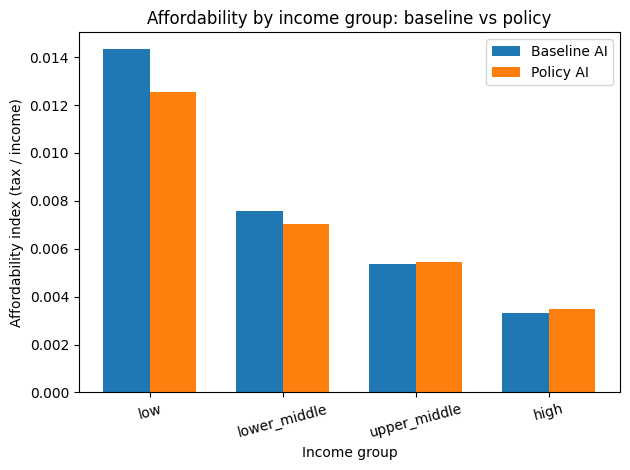

In [77]:
import matplotlib.pyplot as plt

summary_compare = summary_compare.sort_values("mean_income")

x = np.arange(len(summary_compare))
width = 0.35

fig, ax = plt.subplots()
ax.bar(x, summary_compare["AI_base"], width, label="Baseline AI")
ax.bar(x + width, summary_compare["AI_policy"], width, label="Policy AI")

ax.set_xticks(x + width/2)
ax.set_xticklabels(summary_compare.index, rotation=15)
ax.set_xlabel("Income group")
ax.set_ylabel("Affordability index (tax / income)")
ax.set_title("Affordability by income group: baseline vs policy")
ax.legend()
plt.tight_layout()
plt.show()


In [78]:
import numpy as np

def weighted_gini(x, w):
    x = np.asarray(x, dtype=float)
    w = np.asarray(w, dtype=float)

    mask = (w > 0) & (x >= 0)
    x = x[mask]
    w = w[mask]

    order = np.argsort(x)
    x = x[order]
    w = w[order]

    W = w.sum()
    Y = (x * w).sum()
    if W == 0 or Y == 0:
        return np.nan

    cum_w = np.cumsum(w)
    cum_y = np.cumsum(x * w)

    cum_w_share = np.insert(cum_w / W, 0, 0)
    cum_y_share = np.insert(cum_y / Y, 0, 0)

    # Area under Lorenz line
    area = np.trapezoid(cum_y_share, cum_w_share)

    # Gini = 1 - 2 * area
    return 1 - 2 * area


In [79]:
gini_w_before = weighted_gini(df["annual_income_usd"], df["hh_weight"])
gini_w_after_base = weighted_gini(df["income_after_base"], df["hh_weight"])
gini_w_after_policy = weighted_gini(df["income_after_policy"], df["hh_weight"])

print("Weighted Gini before RUC       :", gini_w_before)
print("Weighted Gini after RUC (base) :", gini_w_after_base)
print("Weighted Gini after policy     :", gini_w_after_policy)


Weighted Gini before RUC       : 0.4261285118536251
Weighted Gini after RUC (base) : 0.4272679555797094
Weighted Gini after policy     : 0.42714088705158804
